# Candidate explanations for the ~10x surface-concentration gap

Companion to `flux_amplification_decomposition.ipynb`, which explains the ~1.6-1.8x peak *flux* differences across the four intervention sites (Japan J, Vancouver Island V, Baja California B, Ecuador E). Surface tracer *concentration* differs by roughly **10x** across sites -- much more than flux alone can explain -- so this notebook investigates two further candidates:

1. **Vertical mixing depth**
2. **Horizontal transport / residence time**: does weaker surface advection let tracer accumulate locally at some sites?

In [31]:
import glob
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs

from roms_tools import Grid
from plot import _finish_panel, _plot_colorbar, ZOOM_COORDS, gaussian_footprint_mask

In [32]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
theta_s, theta_b, hc, N = 6.0, 6.0, 250.0, 100
grid = Grid.from_file(grid_file, theta_s=theta_s, theta_b=theta_b, hc=hc, N=N)

# Same locations and grid indices as in make_tracer_surface_flux.ipynb
locations = {
    "Japan": (710, 459),
    "Vancouver Island": (855, 1135),
    "Baja California": (650, 1290),
    "Ecuador": (490, 1640),
}
_release_prefix = {"Japan": "JP", "Vancouver Island": "VI", "Baja California": "BC", "Ecuador": "EC"}

lon, lat = grid.ds.lon_rho, grid.ds.lat_rho
area = 1 / (grid.ds.pm * grid.ds.pn)
ocean_area = area.where(grid.ds.mask_rho)

release_centers = {
    name: (float(lon.isel(eta_rho=eta, xi_rho=xi)), float(lat.isel(eta_rho=eta, xi_rho=xi)))
    for name, (eta, xi) in locations.items()
}

2026-08-31 01:13:15 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-08-31 01:13:15 - INFO - Total time: 0.003 seconds
2026-08-31 01:13:15 - INFO - ================================================================================================


In [33]:
# Same per-experiment palette as curves.ipynb / linearity_cdr_tracer.ipynb; always use the
# "7" (100x, medium-amplitude) shade for line color here, regardless of which amp is plotted --
# the medium shades are easier to tell apart than the darkest ("8") ones.
colors = {
    "JP10": "#d4b9da", "JP7": "#df65b0", "JP8": "#980043",
    "VI10": "#A8E6A3", "VI7": "#4CAF50", "VI8": "#1B5E20",
    "BC10": "#A7C7E7", "BC7": "#2196F3", "BC8": "#0D47A1",
    "EC10": "#FFD580", "EC7": "#FFA500", "EC8": "#CC5500",
}



In [34]:
# Tracers available to overlay as a mass-weighted contour (see mass_contour_level below), keyed
# by short name for `plot_mld_map`'s/`plot_mean_speed_map`'s `footprints` argument: (cache field
# name, marbl dir, display label, line color).
mass_tracer_registry = {
    "oae_dalk": ("alk_oae", "roms_marbl_alk", r"OAE $\delta$ALK", "red"),
    "oae_ddic": ("dic_oae", "roms_marbl_alk", r"OAE $\delta$DIC", "blue"),
    "dor_ddic": ("dic_dor", "roms_marbl_dic", r"DOR $\delta$DIC", "purple"),
}


def mass_contour_level(field, area, mass_frac=0.9):
    """Density threshold tau such that {|field| >= tau} is the smallest-area region whose
    mass (|field| * area, summed over the highest-density cells first) reaches `mass_frac`
    of the total mass -- i.e. tau is the contour level for a mass-weighted highest-density
    region. field may be signed (e.g. DOR's dDIC is negative), hence the abs().
    """
    f = np.abs(field.values).ravel()
    a = area.values.ravel()
    valid = np.isfinite(f) & np.isfinite(a)
    f, a = f[valid], a[valid]
    order = np.argsort(f)[::-1]
    cum_mass = np.cumsum((f * a)[order])
    idx = np.searchsorted(cum_mass, mass_frac * cum_mass[-1])
    return f[order][idx]


def load_mass_footprint(name, amp, date, marbl_dir):
    """Load the depth-integrated column-inventory field(s) for one site/date from the cache
    written by compute_mass_footprint.py in `marbl_dir` (roms_marbl_alk or roms_marbl_dic),
    masked to ocean cells."""
    exp = f"{_release_prefix[name]}{amp}"
    # roms_marbl_alk experiment dirs are currently named exp<SITE><AMP>_perlmutter (Anvil-sourced
    # copies of the same names, without the suffix, are being restored but aren't reliable yet --
    # hardcoded rather than falling back to them).
    dir_name = f"exp{exp}_perlmutter" if marbl_dir == "roms_marbl_alk" else f"exp{exp}"
    cache = Path(f"{marbl_dir}/{dir_name}/OUTPUT/MASS_FOOTPRINT/mass_footprint_{date}.nc")
    if not cache.exists():
        raise FileNotFoundError(
            f"{cache} not found -- run 'python compute_mass_footprint.py --exp {exp} "
            f"--date {date}' in {marbl_dir}/workflows/ first."
        )
    footprint = xr.open_dataset(cache)
    return footprint.where(grid.ds.mask_rho)

## Vertical mixing depth


In [48]:
def plot_vertical_mixing_profiles(date, amp="8", max_depth=500, save=True,
                                  panel_labels=None, show_date=False, normalized=False,
                                  norm_style="density"):
    """Plot the domain-total vertical inventory density (mmol/m) profiles for DOR dDIC, OAE dALK,
    and OAE dDIC for the four sites at a given release date, from precomputed caches. Returns
    (fig, profiles).

    Caches are written by roms_marbl_dic/workflows/compute_vertical_profile.py (DOR) and
    roms_marbl_alk/workflows/compute_vertical_profile.py (OAE); run
    `python compute_vertical_profile.py --exp <SITE><AMP> --date <DATE>` for each site in both
    workflows/ dirs first if this raises a FileNotFoundError.

    Each cache already reports mmol/m on a fixed-spacing depth grid (5 m by default): the
    cumulative dz-weighted column mass is linearly regridded, in physical depth, from the
    model's terrain-following s_rho layers onto fixed depth bins before summing over the
    domain (a raw s_rho index sits at different physical depths in different water columns
    and isn't a real depth level on its own). The bin spacing is coarser than the ~1 m native
    top-layer thickness on purpose, to average out sigma-layer-alignment artifacts rather than
    resolve them.

    panel_labels : tuple of 3 str, optional
        Prefix each panel title with e.g. "(a)"/"(b)"/"(c)" -- pass panel_labels=("a", "b", "c")
        (or any 3 labels) to enable; None (default) leaves titles unprefixed.
    show_date : bool, optional
        If True, append `date` (reformatted from "YYYYMMDD" to "YYYY-MM-DD" if applicable) to
        each panel's title. Default False.
    normalized : bool, optional
        If True, normalize each profile by its own depth-integrated total (i.e. total injected
        mass) so panels compare the *shape* of the vertical distribution across sites rather
        than the raw mass density (mmol/m). Default False. See `norm_style` for the two ways
        this is rendered.
    norm_style : {"histogram", "density"}, optional
        Only used when `normalized=True`.
        - "histogram": plot the per-bin fraction of total mass (`100 * x / x.sum()`,
          in % of total mass per depth bin, summing to 100% over the column) as a stepped
          histogram outline. Honest about the fact that the plotted number is a binned mass
          fraction that scales with the bin width, not a continuous density.
        - "density"  (default): plot the fraction of total mass *per meter* (`100 * x / (x.sum() * dz)`,
          in % of total mass / m) as a smooth line -- bin-width-independent, and just a
          per-site rescaling of the mmol/m panel.
    """
    profiles = {}
    for name in locations:
        exp = f"{_release_prefix[name]}{amp}"
        dor_cache = Path(f"roms_marbl_dic/exp{exp}/OUTPUT/VERTICAL_PROFILE/vertical_profile_{date}.nc")
        # roms_marbl_alk experiment dirs are currently named exp<SITE><AMP>_perlmutter (Anvil-sourced
        # copies of the same names, without the suffix, are being restored but aren't reliable yet --
        # hardcoded rather than falling back to them).
        #oae_cache = Path(f"roms_marbl_alk/exp{exp}_perlmutter/OUTPUT/VERTICAL_PROFILE/vertical_profile_{date}.nc")
        oae_cache = Path(f"roms_marbl_alk/exp{exp}/OUTPUT/VERTICAL_PROFILE/vertical_profile_{date}.nc")

        for cache in (dor_cache, oae_cache):
            if not cache.exists():
                raise FileNotFoundError(
                    f"{cache} not found -- run 'python compute_vertical_profile.py --exp {exp} "
                    f"--date {date}' in {cache.parts[0]}/workflows/ first."
                )
        dor_ds = xr.open_dataset(dor_cache)
        oae_ds = xr.open_dataset(oae_cache)
        if normalized:
            def _norm(da, depth_da):
                # da is already mmol/m on a fixed-depth grid. "histogram" -> % of total mass
                # per bin (divide by the sum over equal-width bins). "density" -> % of total
                # mass per meter (additionally divide by the bin width dz).
                total = da.sum()
                if norm_style == "density":
                    dz = float(np.median(np.diff(np.asarray(depth_da.values, dtype=float))))
                    return 100 * da / (total * dz)
                return 100 * da / total

            profiles[name] = xr.Dataset({
                "dic_dor": _norm(dor_ds.dic_dor, dor_ds.depth_dor),
                "depth_dor": dor_ds.depth_dor,
                "alk_oae": _norm(oae_ds.alk_oae, oae_ds.depth_oae),
                "dic_oae": _norm(oae_ds.dic_oae, oae_ds.depth_oae),
                "depth_oae": oae_ds.depth_oae,
            })
        else:
            profiles[name] = xr.Dataset({
                "dic_dor": dor_ds.dic_dor,
                "depth_dor": dor_ds.depth_dor,
                "alk_oae": oae_ds.alk_oae,
                "dic_oae": oae_ds.dic_oae,
                "depth_oae": oae_ds.depth_oae,
            })

    tracer_cols = [
        ("alk_oae", "depth_oae", r"OAE: $\delta$ALK"),
        ("dic_oae", "depth_oae", r"OAE: $\delta$DIC"),
        ("dic_dor", "depth_dor", r"DOR: $\delta$DIC"),
    ]
    if panel_labels:
        tracer_cols = [
            (var_key, depth_key, f"({label}) {title}")
            for (var_key, depth_key, title), label in zip(tracer_cols, panel_labels)
        ]
    if show_date:
        date_str = f"{date[:4]}-{date[4:6]}-{date[6:8]}" if len(date) == 8 and date.isdigit() else str(date)
        tracer_cols = [(var_key, depth_key, f"{title} ({date_str})") for var_key, depth_key, title in tracer_cols]

    hist = normalized and norm_style == "histogram"

    def _edges_from_mid(d):
        d = np.asarray(d, dtype=float)
        dd = np.diff(d)
        return np.concatenate([[d[0] - dd[0] / 2], d[:-1] + dd / 2, [d[-1] + dd[-1] / 2]])

    fig, axs = plt.subplots(1, 3, figsize=(10, 5))
    for col, (var_key, depth_key, title) in enumerate(tracer_cols):
        ax = axs[col]
        for name in locations:
            ds_p = profiles[name]
            line_color = colors[f"{_release_prefix[name]}7"]
            if hist:
                # stepped histogram outline in (value, depth) space: each bin's value held
                # constant over its depth range, connected by horizontal jumps between bins.
                edges = _edges_from_mid(ds_p[depth_key].values)
                v = np.asarray(ds_p[var_key].values, dtype=float)
                ax.plot(np.repeat(v, 2), np.repeat(edges, 2)[1:-1],
                        label=name, color=line_color, lw=2)
            else:
                ax.plot(ds_p[var_key], ds_p[depth_key], label=name, color=line_color, lw=2)
        ax.axvline(0, color="gray", linewidth=1)
        ax.set_ylim(max_depth, 0)
        ax.set_title(title)
        if not normalized:
            ax.set_xlabel("mmol/m")
        elif norm_style == "density":
            ax.set_xlabel("% of total mass / m")
        else:
            ax.set_xlabel("% of total mass per bin")
        ax.grid()
        if not normalized:
            # "x10^n" instead of matplotlib's default "1en" offset-text style
            ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
        if col == 0:
            ax.set_ylabel("Depth (m)")
        if col == 2:
            if normalized:
                ax.legend(loc="lower right")
            else:
                ax.legend(loc="lower left")
        else:
            ax.legend(loc="lower right")
            
    plt.tight_layout()

    if save:
        suffix = f"_normalized_{norm_style}" if normalized else ""
        fig.savefig(f"figures/vertical_mixing_profiles{suffix}_{date}_amp{amp}.png", dpi=300, bbox_inches="tight")

    return fig, profiles

### After 1 month

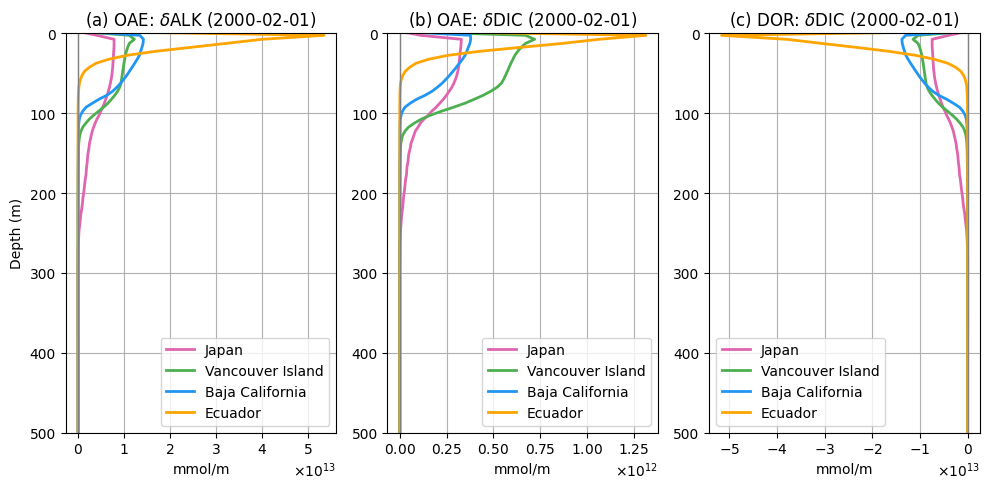

In [49]:
fig, profiles = plot_vertical_mixing_profiles("20000201", panel_labels=("a", "b", "c"), show_date=True)

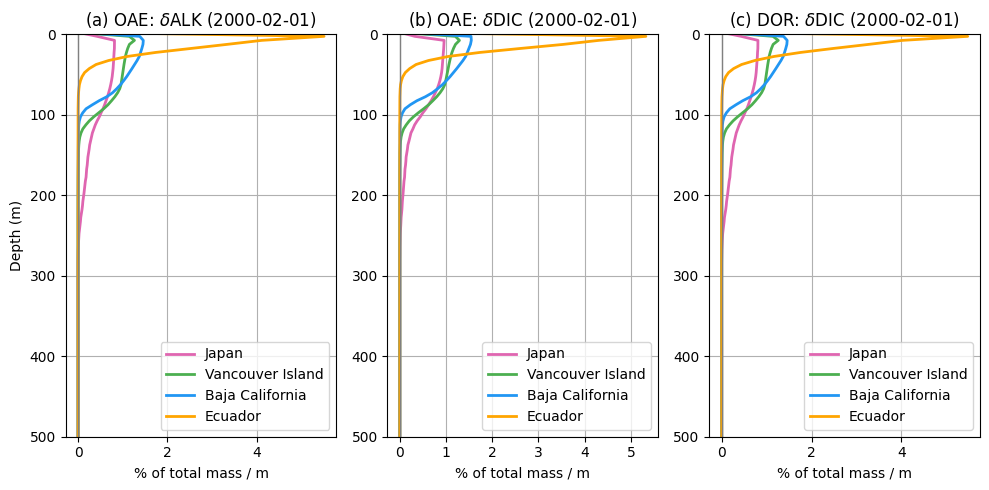

In [50]:
fig, _ = plot_vertical_mixing_profiles("20000201", panel_labels=("a", "b", "c"), show_date=True, normalized=True)

### After 6 months

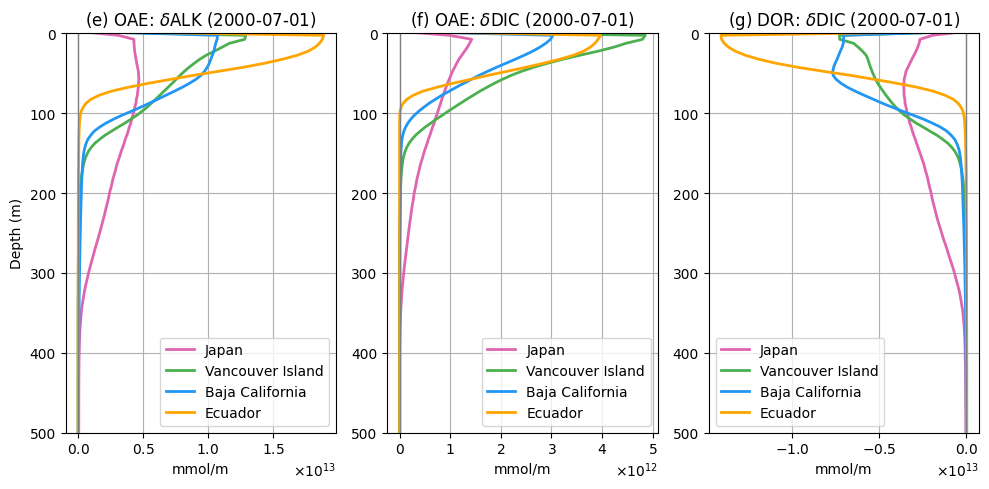

In [51]:
fig, profiles = plot_vertical_mixing_profiles("20000701", panel_labels=("e", "f", "g"), show_date=True)

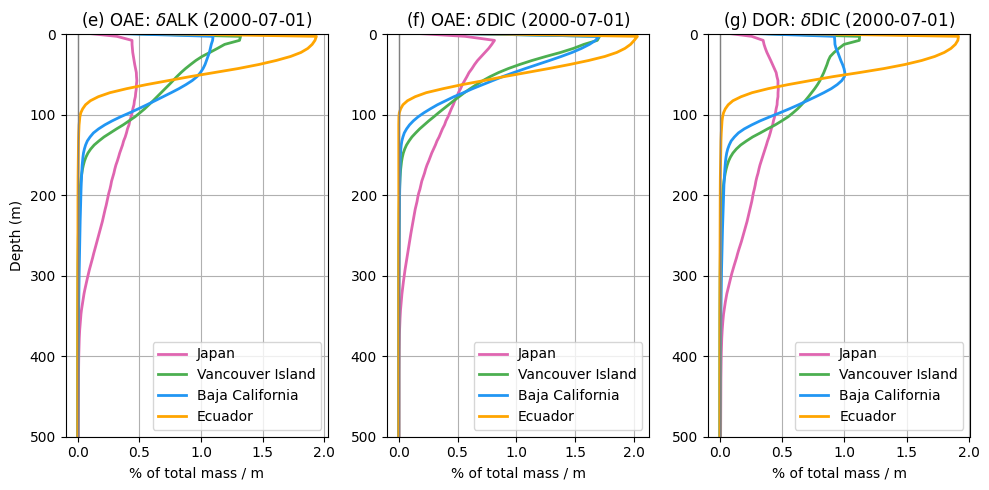

In [52]:
fig, profiles_norm = plot_vertical_mixing_profiles("20000701", panel_labels=("e", "f", "g"), show_date=True, normalized=True)

### After 1 year

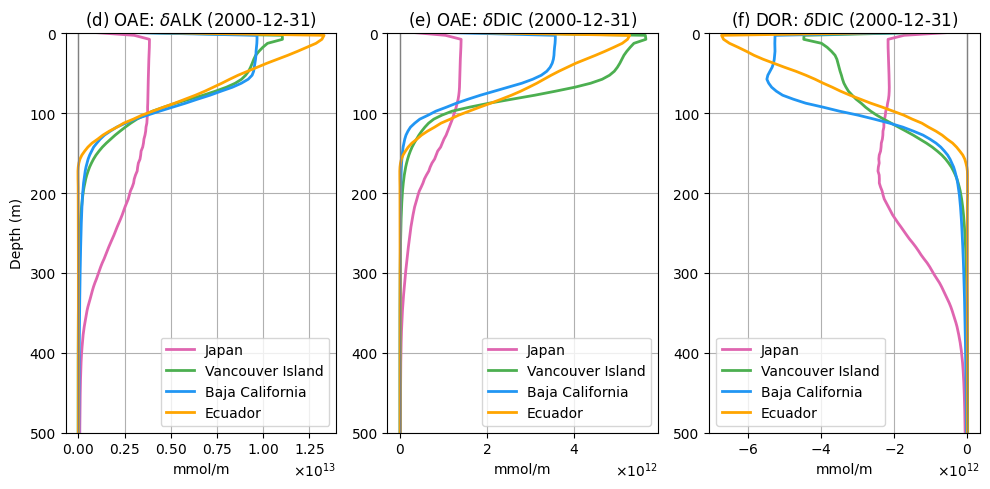

In [53]:
fig, profiles = plot_vertical_mixing_profiles("20001231", panel_labels=("d", "e", "f"), show_date=True)

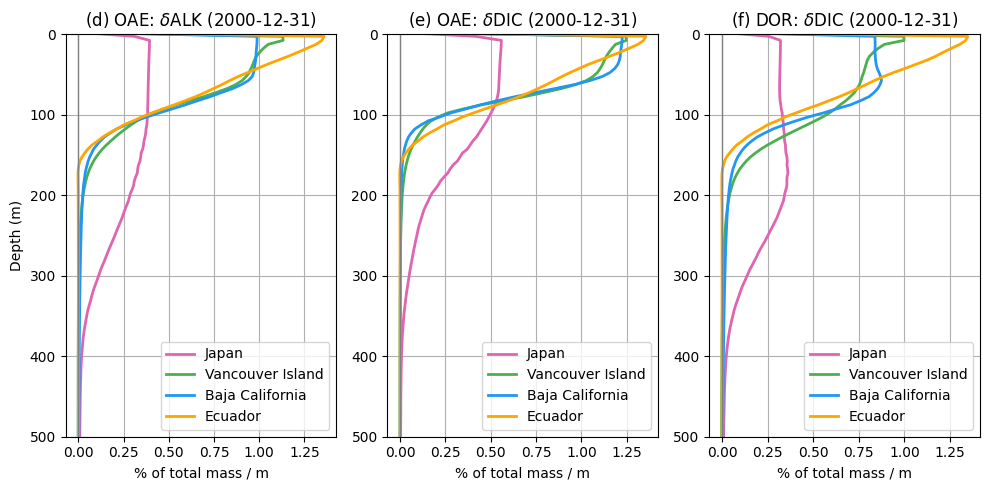

In [54]:
fig, profiles_norm = plot_vertical_mixing_profiles("20001231", panel_labels=("d", "e", "f"), show_date=True, normalized=True)

### After 2 years

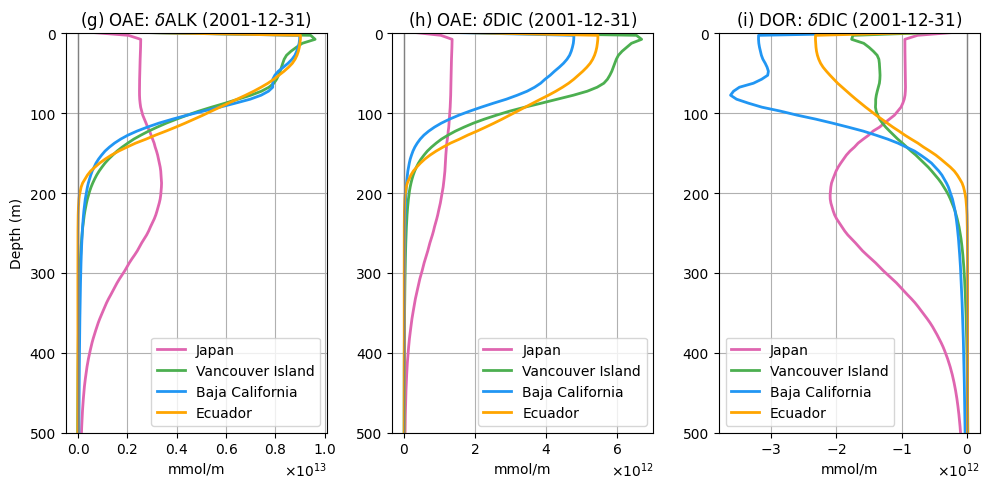

In [55]:
fig, profiles = plot_vertical_mixing_profiles("20011231", panel_labels=("g", "h", "i"), show_date=True)

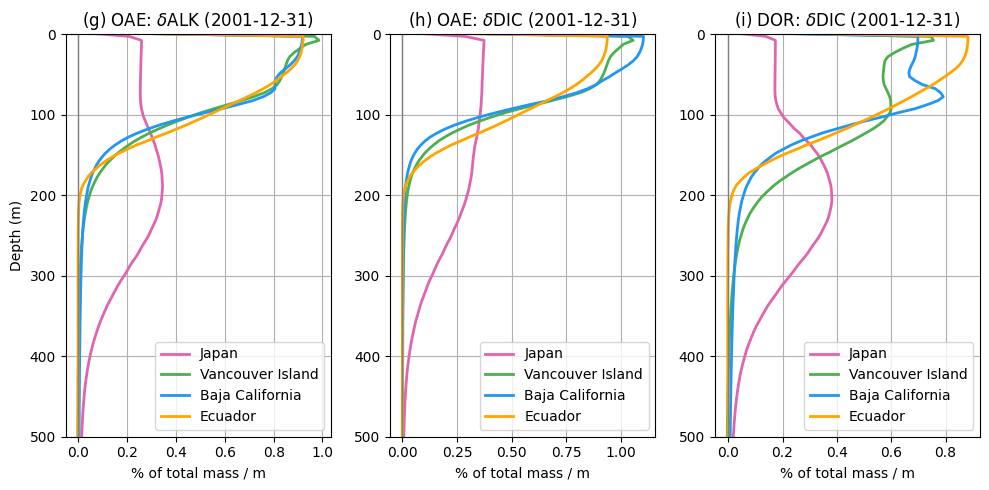

In [56]:
fig, profiles_norm = plot_vertical_mixing_profiles("20011231", panel_labels=("g", "h", "i"), show_date=True, normalized=True)

## Mixed layer depth (control run)

MLD is defined by a density-threshold criterion (de Boyer Montegut-style): the deepest level where the potential density anomaly (sigma0, from `gsw`) differs from the surface value by less than 0.03 kg/m^3, computed from temp/salt in the physics-only control run (`expVI8/OUTPUT/JOINED_full`, 2000-2001).

In [14]:
mld_field_cache = Path("roms_marbl_dic/expCTRL/MIXED_LAYER_DEPTH/FIELD/mld_field_climatology.nc")
if not mld_field_cache.exists():
    raise FileNotFoundError(
        f"{mld_field_cache} not found -- run 'python compute_mixed_layer_depth_field.py' in "
        "roms_marbl_dic/workflows/ first (a long batch job; see compute_mixed_layer_depth_field.sh)."
    )
mld_field_ds = xr.open_dataset(mld_field_cache)

In [15]:
def plot_mld_map(months=None, vmax=200, save=True, panel_labels=("a", "b", "c", "d"),
                 footprint_date="20000701", amp="8", mass_frac=0.9, footprints="oae_dalk"):
    """2x2 zoomed mixed-layer-depth map, laid out identically to plot_mean_speed_map (same
    regional boxes/projections, colorbar, and release-footprint markers): built from the
    full-domain monthly-climatology MLD field cache (compute_mixed_layer_depth_field.py), each
    cached month already the 2000-2001 mean for that calendar month, so selecting/averaging
    months here is cheap. Since the field covers the whole domain (not a per-site crop), every
    panel fills its zoom box completely, with no missing corners. Each site's regional box
    additionally shows a mass-weighted contour (see mass_contour_level) for the chosen
    `footprints` tracer(s) at `footprint_date` -- the default "oae_dalk" draws a red contour of
    where the OAE plume has spread to by `footprint_date` (2000-07-01, i.e. ~6 months after the
    2000-02-01 release, by default).

    months : int or sequence of int, optional
        Which calendar month(s) to show, e.g. months=1 for a January climatology or
        months=[6, 7, 8] for JJA (an unweighted mean of those months' climatologies -- the
        standard convention for a climatological seasonal/annual mean). Default (None) averages
        all 12 months for the overall climatological mean, i.e. the time-mean MLD.
    footprint_date, amp, mass_frac, footprints : see plot_mean_speed_map -- same meaning here.
    """
    sel_months = list(range(1, 13)) if months is None else (
        [months] if isinstance(months, int) else sorted(months)
    )
    if isinstance(footprints, str):
        footprints = (footprints,)
    mass_tracers = [mass_tracer_registry[key] for key in footprints]
    date_str = f"{footprint_date[:4]}-{footprint_date[4:6]}-{footprint_date[6:8]}"

    field_mean = mld_field_ds.mld.sel(month=sel_months).mean(dim="month").where(grid.ds.mask_rho)

    fig, axs = plt.subplots(2, 2, figsize=(11, 10))
    axs = axs.flatten()
    p = None
    for i, name in enumerate(locations):
        zc = ZOOM_COORDS[name]
        lon_min, lon_max, lat_min, lat_max = zc["lon_min"], zc["lon_max"], zc["lat_min"], zc["lat_max"]
        proj = ccrs.LambertConformal(
            central_longitude=(lon_min + lon_max) / 2, central_latitude=(lat_min + lat_max) / 2,
        )
        axs[i].remove()
        axs[i] = fig.add_subplot(2, 2, i + 1, projection=proj)

        p = axs[i].pcolormesh(lon, lat, field_mean, transform=ccrs.PlateCarree(),
                              cmap="viridis", vmin=0, vmax=vmax)

        footprint_cache = {}
        for field_key, marbl_dir, label, color in mass_tracers:
            if marbl_dir not in footprint_cache:
                footprint_cache[marbl_dir] = load_mass_footprint(name, amp, footprint_date, marbl_dir)
            field = footprint_cache[marbl_dir][field_key]
            tau = mass_contour_level(field, ocean_area, mass_frac)
            axs[i].contour(lon, lat, np.abs(field), levels=[tau], colors=color,
                           linewidths=1.5, transform=ccrs.PlateCarree(), zorder=4)

        axs[i].set_title(f"({panel_labels[i]}) {name}")
        _finish_panel(axs[i], lon_min, lon_max, lat_min, lat_max, loc=name, release_centers=release_centers)

    cbar = fig.colorbar(p, ax=list(axs), orientation="horizontal", shrink=0.6, pad=0.05, extend="max")
    cbar_label = "Mixed layer depth (m)"
    cbar.set_label(cbar_label)

    legend_handles = [
        plt.Line2D([0], [0], color=color, lw=2,
                  label=f"{label}: {int(mass_frac * 100)}% mass ({date_str})")
        for _, _, label, color in mass_tracers
    ]
    legend_handles.append(
        plt.Line2D([0], [0], color="black", linestyle="--", lw=1.5,
                   label="90% Gaussian intervention footprint")
    )
    fig.legend(handles=legend_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.08), framealpha=1, facecolor="#d9d9d9")

    month_names = ["January", "February", "March", "April", "May", "June", "July",
                  "August", "September", "October", "November", "December"]
    if months is None:
        title = "Time-mean over 2000-2001"
    else:
        title = f"{', '.join(month_names[m - 1] for m in sel_months)}, 2000-2001"

    fig.suptitle(title, y=0.95)
    if save:
        suffix = "" if months is None else f"_months{'-'.join(map(str, sel_months))}"
        fig.savefig(f"figures/mixed_layer_depth_map{suffix}.png", dpi=300, bbox_inches="tight")

    return fig

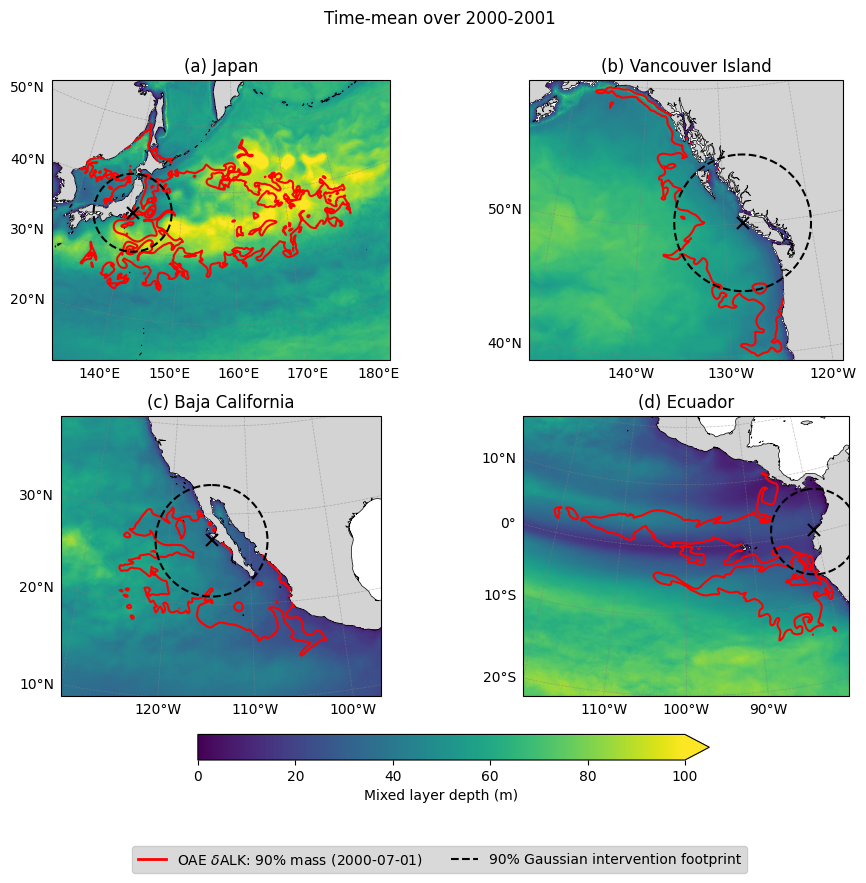

In [16]:
fig = plot_mld_map(vmax=100)

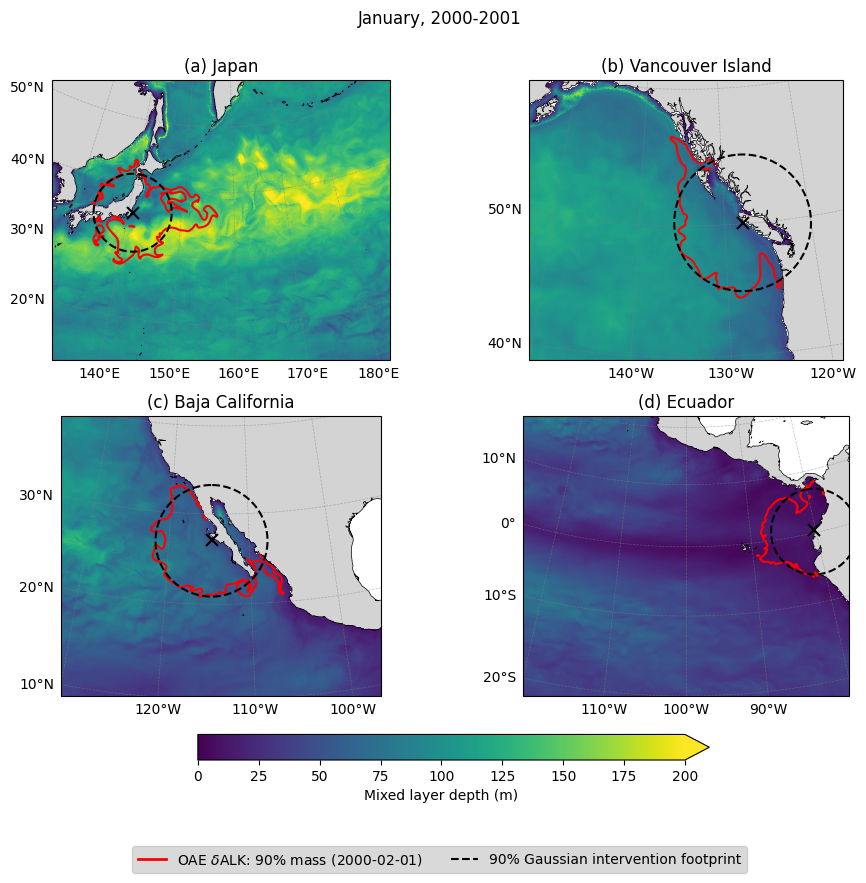

In [17]:
fig = plot_mld_map(months=1, vmax=200, footprint_date="20000201")

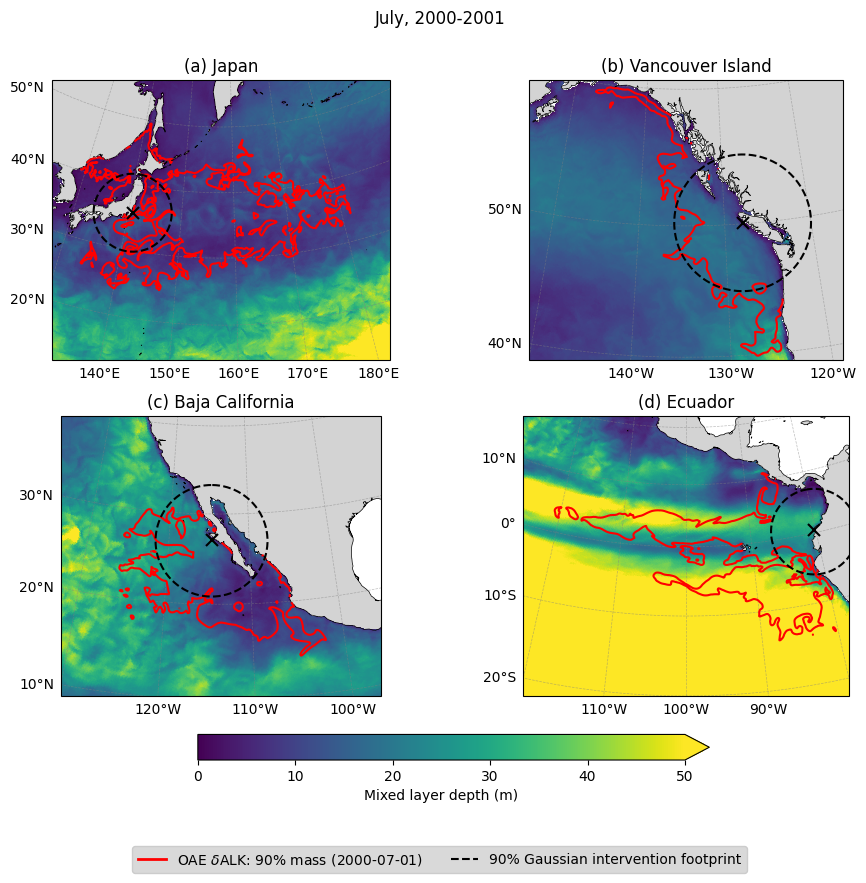

In [18]:
fig = plot_mld_map(months=7, vmax=50, footprint_date="20000701")

### Seasonal cycle at each site

In [19]:
def plot_mld_seasonal_cycle(save=True):
    """12-month climatological MLD seasonal cycle at each site: area-weighted mean of
    `mld_field_climatology.nc` over the site's 90% Gaussian intervention footprint
    (`gaussian_footprint_mask`), one line per site. Returns (fig, seasonal), where `seasonal`
    is a dict of site name -> xr.DataArray (dim "month", 1-12).
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    seasonal = {}
    for name in locations:
        mask = xr.DataArray(gaussian_footprint_mask(grid, name, release_centers),
                            dims=("eta_rho", "xi_rho"))
        weights = ocean_area.where(mask)
        monthly_mean = (mld_field_ds.mld * weights).sum(dim=("eta_rho", "xi_rho")) / weights.sum(dim=("eta_rho", "xi_rho"))
        seasonal[name] = monthly_mean

        line_color = colors[f"{_release_prefix[name]}7"]
        ax.plot(monthly_mean.month, monthly_mean, marker="o", color=line_color, lw=2, label=name)

    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Mixed layer depth (m)")
    ax.set_title("Climatological MLD seasonal cycle (2000-2001)")
    ax.grid()
    ax.legend()

    if save:
        fig.savefig("figures/mld_seasonal_cycle.png", dpi=300, bbox_inches="tight")

    return fig, seasonal

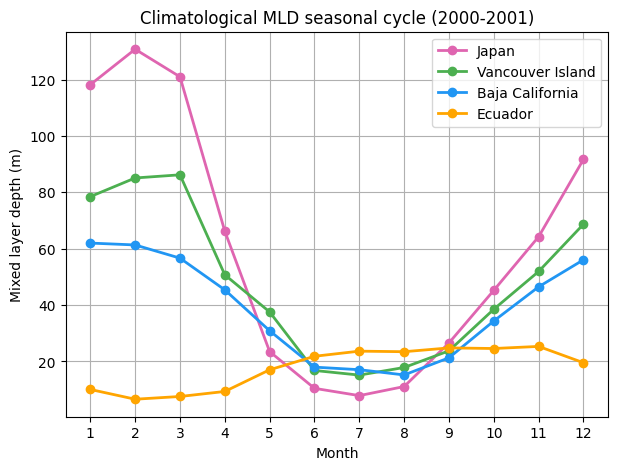

In [20]:
fig, mld_seasonal = plot_mld_seasonal_cycle()

## Current speed

In [21]:
# Regional per-site boxes, used for the zoomed spatial map in Section 2.
# Now centralized in plot.py (ZOOM_COORDS) so it only needs editing in one place.
regional_zoom_coords = {name: ZOOM_COORDS[name] for name in locations}

# Wider version of the same boxes, for panels that want to zoom out further (e.g. the later
# release dates in Section 2, where the tracer has spread beyond the regular box). Seeded here
# as a 2x-wider box around each regular box's center -- tweak per site as needed.
regional_zoom_coords_wide = {
    "Japan": {"lon_min": 107.5, "lon_max": 207.5, "lat_min": -5, "lat_max": 75},
    "Vancouver Island": {"lon_min": -165.5, "lon_max": -103.5, "lat_min": 20, "lat_max": 70.5},
    "Baja California": {"lon_min": -146.5, "lon_max": -80.5, "lat_min": -5, "lat_max": 55},
    "Ecuador": {"lon_min": -200, "lon_max": -80, "lat_min": -90, "lat_max": 30},
}

In [22]:
# Precomputed by roms_marbl_dic/workflows/compute_mean_surface_velocity.py (2000-2001)
mean_velocity_cache = Path("roms_marbl_dic/expCTRL/MEAN_VELOCITY/mean_surface_velocity.nc")
if not mean_velocity_cache.exists():
    raise FileNotFoundError(
        f"{mean_velocity_cache} not found -- run "
        "roms_marbl_dic/workflows/compute_mean_surface_velocity.py first."
    )
mean_vel_ds = xr.open_dataset(mean_velocity_cache)
mean_speed_field = mean_vel_ds.speed_mean.where(grid.ds.mask_rho)

# u_mean/v_mean are grid-relative (xi, eta); rotate to true east/north using the grid angle
angle = grid.ds.angle
mean_u_true = (mean_vel_ds.u_mean * np.cos(angle) - mean_vel_ds.v_mean * np.sin(angle)).where(grid.ds.mask_rho)
mean_v_true = (mean_vel_ds.u_mean * np.sin(angle) + mean_vel_ds.v_mean * np.cos(angle)).where(grid.ds.mask_rho)

In [23]:
stride = 15  # grid points between arrows
speed_threshold = 0.3  # m/s -- only draw arrows where the mean flow exceeds this

sl = dict(eta_rho=slice(None, None, stride), xi_rho=slice(None, None, stride))
lon_sub = lon.isel(**sl).values
lat_sub = lat.isel(**sl).values


def get_quiver_data():
    """Subsampled u/v/speed at the module-level `stride`.

    """
    u_field, v_field = (mean_u_true, mean_v_true)
    u_sub = u_field.isel(**sl).values
    v_sub = v_field.isel(**sl).values
    speed_sub = np.sqrt(u_sub**2 + v_sub**2)
    quiver_mask = speed_sub >= speed_threshold
    return u_sub, v_sub, speed_sub, quiver_mask


In [24]:
def plot_mean_speed_map(footprint_date="20000701", vmax=0.6, save=True, panel_labels=("a", "b", "c", "d"),
                        zoom_coords=None, amp="8", mass_frac=0.9, footprints="oae_dalk"):
    """2x2 zoomed 2000-2001 time-mean surface-current-speed map, laid out identically to
    `plot_mld_map` (same projections, colorbar, and release-footprint markers): built from the
    cached `mean_speed_field` (compute_mean_surface_velocity.py). Arrows show the mean current
    direction (rotated from grid-relative to true east/north via the grid's `angle` field, see
    `get_quiver_data`), drawn only where the mean speed exceeds the module-level
    `speed_threshold` m/s, so the quiet background doesn't clutter the plot. Each site's
    regional box additionally shows a mass-weighted contour (see mass_contour_level) for the
    chosen `footprints` tracer(s) at `footprint_date` -- the default "oae_dalk" draws a red
    contour of where the OAE plume has spread to by `footprint_date`.

    zoom_coords : dict, optional
        Per-site {"lon_min", "lon_max", "lat_min", "lat_max"} boxes, keyed by location name.
        Default (None) uses `regional_zoom_coords`; pass `regional_zoom_coords_wide` for a
        zoomed-out view (e.g. for later release dates, where the tracer has spread beyond the
        regular box).
    footprint_date, amp, mass_frac, footprints : see plot_mld_map -- same meaning here.
    """
    if zoom_coords is None:
        zoom_coords = regional_zoom_coords
    if isinstance(footprints, str):
        footprints = (footprints,)
    mass_tracers = [mass_tracer_registry[key] for key in footprints]
    date_str = f"{footprint_date[:4]}-{footprint_date[4:6]}-{footprint_date[6:8]}"

    u_sub, v_sub, speed_sub, quiver_mask = get_quiver_data()

    fig, axs = plt.subplots(2, 2, figsize=(11, 10))
    axs = axs.flatten()
    p = None
    for i, name in enumerate(locations):
        zc = zoom_coords[name]
        lon_min, lon_max, lat_min, lat_max = zc["lon_min"], zc["lon_max"], zc["lat_min"], zc["lat_max"]
        proj = ccrs.LambertConformal(
            central_longitude=(lon_min + lon_max) / 2, central_latitude=(lat_min + lat_max) / 2,
        )
        axs[i].remove()
        axs[i] = fig.add_subplot(2, 2, i + 1, projection=proj)

        p = axs[i].pcolormesh(lon, lat, mean_speed_field, transform=ccrs.PlateCarree(),
                              cmap="YlGnBu", vmin=0, vmax=vmax)

        axs[i].quiver(lon_sub[quiver_mask], lat_sub[quiver_mask], u_sub[quiver_mask], v_sub[quiver_mask],
                     transform=ccrs.PlateCarree(), color="white", edgecolor="black", linewidth=0.5,
                     scale=8, width=0.006, zorder=3)

        footprint_cache = {}
        for field_key, marbl_dir, label, color in mass_tracers:
            if marbl_dir not in footprint_cache:
                footprint_cache[marbl_dir] = load_mass_footprint(name, amp, footprint_date, marbl_dir)
            field = footprint_cache[marbl_dir][field_key]
            tau = mass_contour_level(field, ocean_area, mass_frac)
            axs[i].contour(lon, lat, np.abs(field), levels=[tau], colors=color,
                           linewidths=1.5, transform=ccrs.PlateCarree(), zorder=4)

        axs[i].set_title(f"({panel_labels[i]}) {name}")
        _finish_panel(axs[i], lon_min, lon_max, lat_min, lat_max, loc=name, release_centers=release_centers)

    cbar = fig.colorbar(p, ax=list(axs), orientation="horizontal", shrink=0.6, pad=0.05, extend="max")
    cbar.set_label("Time-mean surface current speed (m/s)")

    legend_handles = [
        plt.Line2D([0], [0], color=color, lw=2,
                  label=f"{label}: {int(mass_frac * 100)}% mass ({date_str})")
        for _, _, label, color in mass_tracers
    ]
    legend_handles.append(
        plt.Line2D([0], [0], color="black", linestyle="--", lw=1.5,
                   label="90% Gaussian intervention footprint")
    )
    legend_handles.append(
        plt.Line2D([0], [0], marker=r"$\rightarrow$", linestyle="None", markersize=15,
                   markerfacecolor="white", markeredgecolor="black",
                   label=f"Time-mean surface current direction")
    )
    fig.legend(handles=legend_handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.08), framealpha=1, facecolor="#d9d9d9")

    if save:
        fig.savefig(f"figures/mean_speed_map_{footprint_date}.png", dpi=300, bbox_inches="tight")

    return fig

### After 1 month

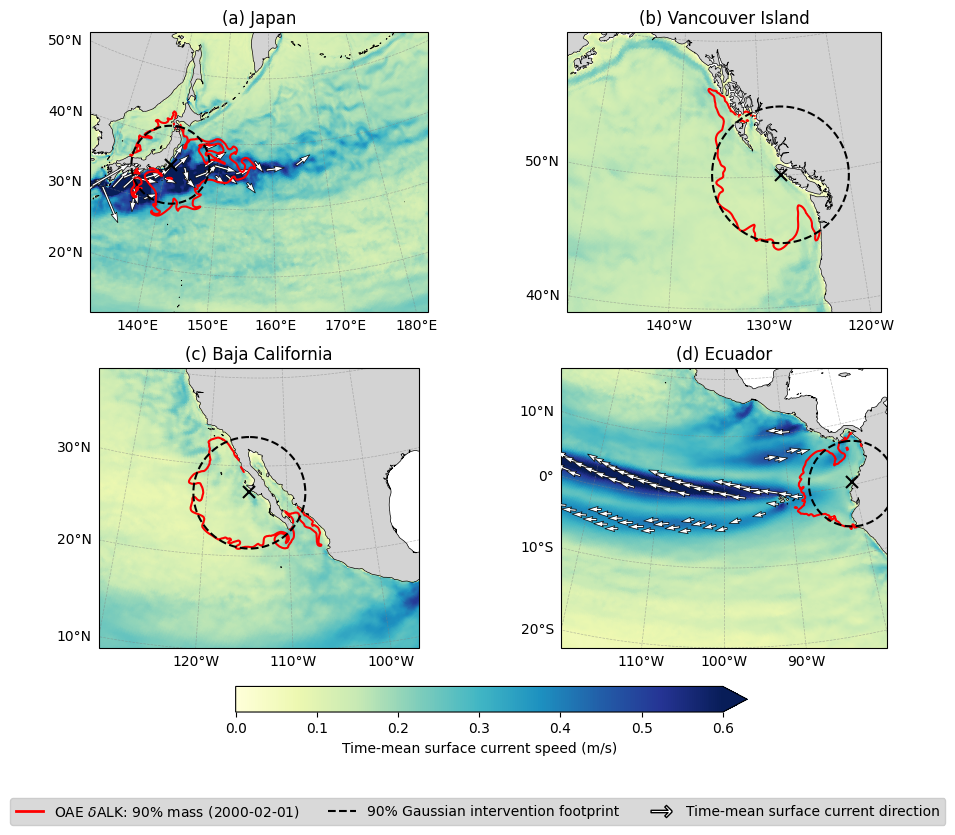

In [25]:
fig = plot_mean_speed_map("20000201")

### After 6 months

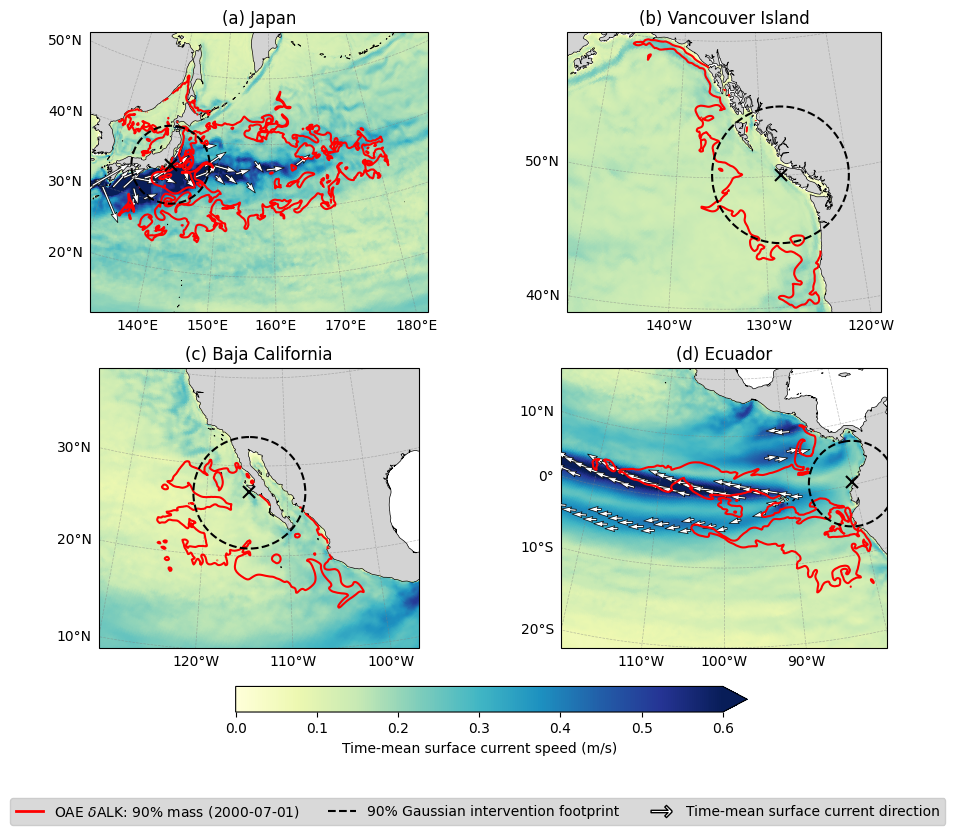

In [26]:
fig = plot_mean_speed_map("20000701")

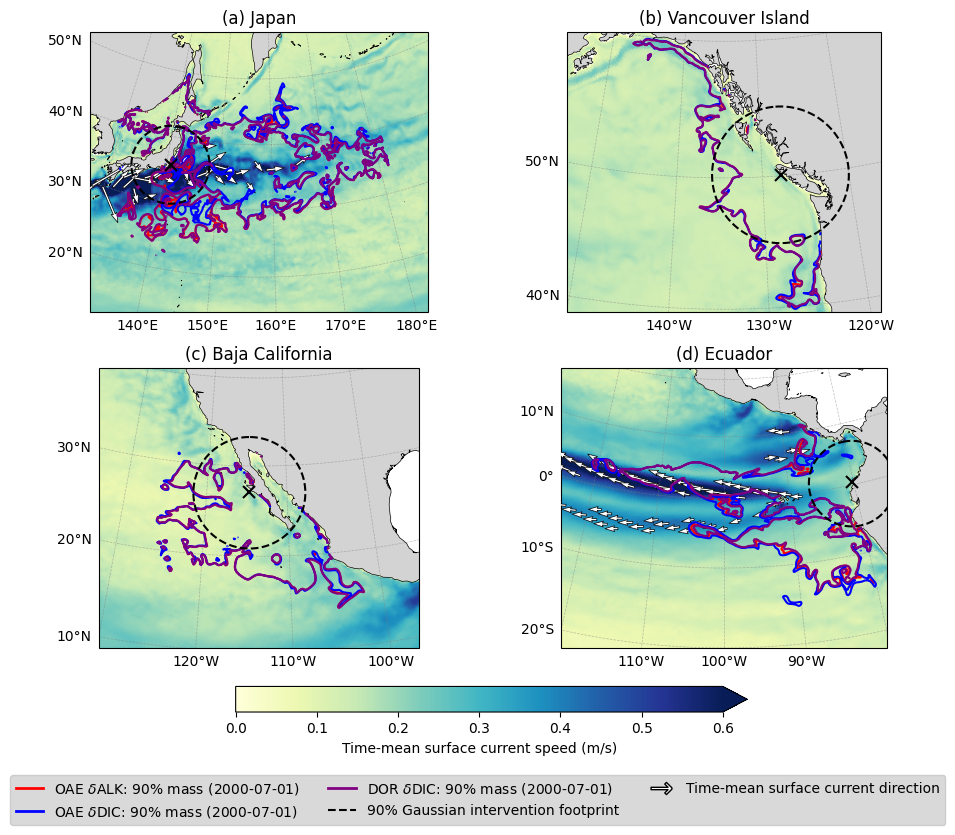

In [27]:
fig = plot_mean_speed_map("20000701", footprints=["oae_dalk", "oae_ddic", "dor_ddic"])

### After 1 year

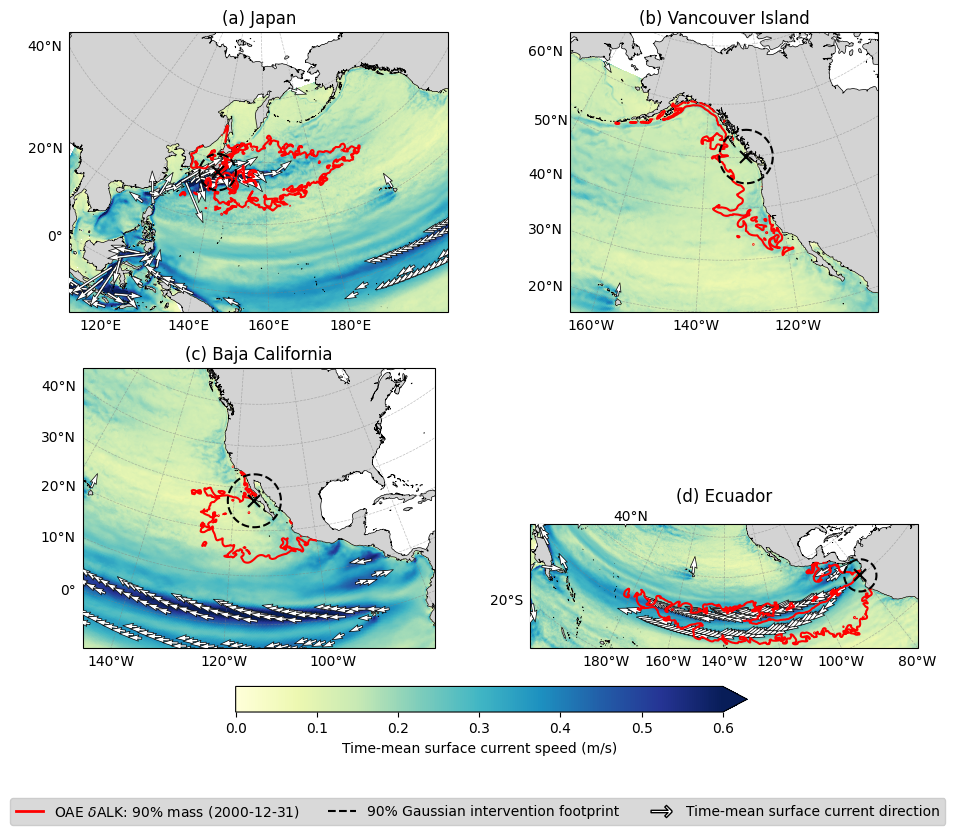

In [28]:
fig = plot_mean_speed_map("20001231", zoom_coords=regional_zoom_coords_wide)

### After 2 years

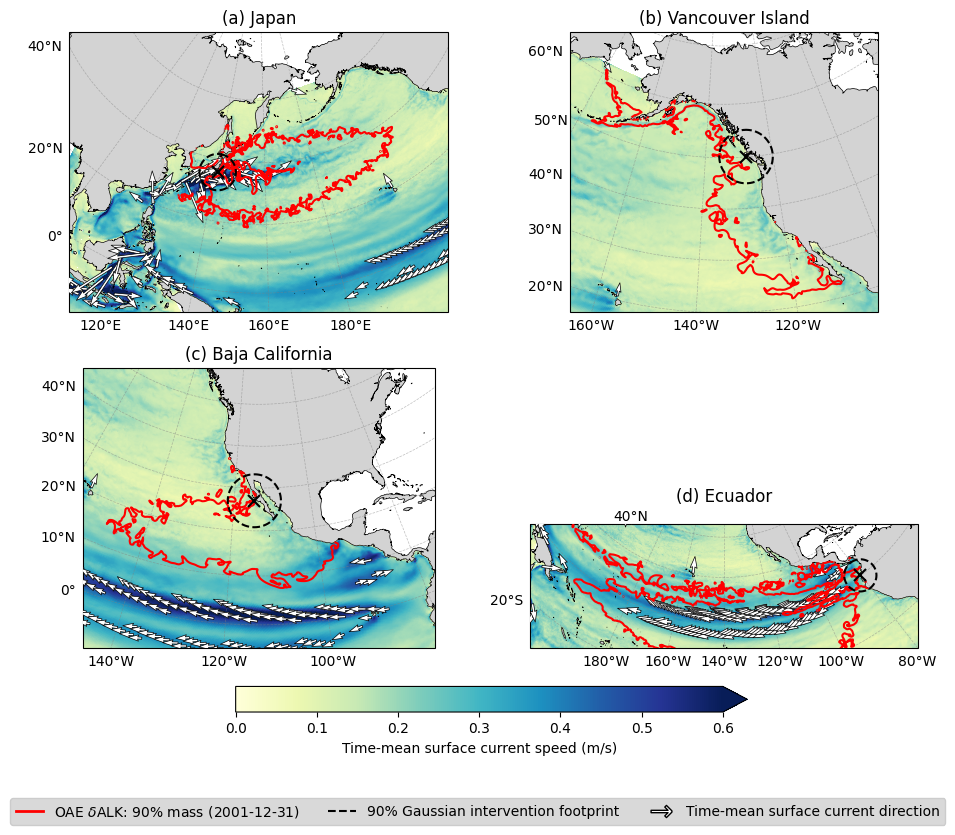

In [29]:
fig = plot_mean_speed_map("20011231", zoom_coords=regional_zoom_coords_wide)